In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("202004-divvy-tripdata.csv")

In [10]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length
0,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152.0,41.8964,-87.6610,41.9322,-87.6586,member,26.816667
1,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499.0,41.9244,-87.7154,41.9306,-87.7238,member,8.150000
2,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255.0,41.8945,-87.6179,41.8679,-87.6230,member,14.383333
3,2A59BBDF5CDBA725,docked_bike,2020-04-07 12:50:19,2020-04-07 13:02:31,California Ave & Division St,216,Wood St & Augusta Blvd,657.0,41.9030,-87.6975,41.8992,-87.6722,member,12.200000
4,27AD306C119C6158,docked_bike,2020-04-18 10:22:59,2020-04-18 11:15:54,Rush St & Hubbard St,125,Sheridan Rd & Lawrence Ave,323.0,41.8902,-87.6262,41.9695,-87.6547,casual,52.916667


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84717 entries, 0 to 84775
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ride_id             84717 non-null  object        
 1   rideable_type       84717 non-null  object        
 2   started_at          84717 non-null  datetime64[ns]
 3   ended_at            84717 non-null  datetime64[ns]
 4   start_station_name  84717 non-null  object        
 5   start_station_id    84717 non-null  int64         
 6   end_station_name    84620 non-null  object        
 7   end_station_id      84620 non-null  float64       
 8   start_lat           84717 non-null  float64       
 9   start_lng           84717 non-null  float64       
 10  end_lat             84620 non-null  float64       
 11  end_lng             84620 non-null  float64       
 12  member_casual       84717 non-null  object        
 13  ride_length         84717 non-null  float64       


In [12]:
df.describe()

,started_at,ended_at,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,ride_length
count,84717,84717,84717.000000,84620.000000,84717.000000,84717.000000,84620.000000,84620.000000,84717.000000
mean,2020-04-15 22:36:46.175726336,2020-04-15 23:12:38.685800960,236.688717,236.979284,41.908154,-87.649317,41.908195,-87.649601,35.875168
min,2020-04-01 00:00:30,2020-04-01 00:10:45,2.000000,2.000000,41.736600,-87.774700,41.736600,-87.774700,0.016667
25%,2020-04-07 22:24:02,2020-04-07 23:24:53,113.000000,113.000000,41.884600,-87.664400,41.884600,-87.665100,8.766667
50%,2020-04-16 15:21:22,2020-04-16 15:46:16,211.000000,212.000000,41.903000,-87.646300,41.903000,-87.646600,16.383333
75%,2020-04-22 19:38:48,2020-04-22 20:14:41,324.000000,323.000000,41.932600,-87.631700,41.932600,-87.631700,28.066667
max,2020-04-30 23:57:20,2020-05-30 15:30:55,673.000000,673.000000,42.064900,-87.549400,42.064900,-87.549400,58720.033333
std,NaN,NaN,160.273682,160.944014,0.043317,0.025170,0.043319,0.025244,567.731952


Data Cleaning 

1) convertibg to date time 

In [13]:
df['started_at']=pd.to_datetime(df['started_at'])

In [14]:
df['ended_at']=pd.to_datetime(df['ended_at'])

2.Creating Ride Length

In [15]:
df['ride_length']=(df['ended_at']-df['started_at']).dt.total_seconds()/60

3.Removing invalid rides

In [16]:
df=df[df['ride_length']>0]

Creating Some New Columns 

In [17]:
df['day_of_week']=df['started_at'].dt.day_name()

In [18]:
df['month'] = df['started_at'].dt.month_name()

In [19]:
df['hour'] = df['started_at'].dt.hour

Verification 

In [20]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week,month,hour
0,A847FADBBC638E45,docked_bike,2020-04-26 17:45:14,2020-04-26 18:12:03,Eckhart Park,86,Lincoln Ave & Diversey Pkwy,152.0,41.8964,-87.6610,41.9322,-87.6586,member,26.816667,Sunday,April,17
1,5405B80E996FF60D,docked_bike,2020-04-17 17:08:54,2020-04-17 17:17:03,Drake Ave & Fullerton Ave,503,Kosciuszko Park,499.0,41.9244,-87.7154,41.9306,-87.7238,member,8.150000,Friday,April,17
2,5DD24A79A4E006F4,docked_bike,2020-04-01 17:54:13,2020-04-01 18:08:36,McClurg Ct & Erie St,142,Indiana Ave & Roosevelt Rd,255.0,41.8945,-87.6179,41.8679,-87.6230,member,14.383333,Wednesday,April,17
3,2A59BBDF5CDBA725,docked_bike,2020-04-07 12:50:19,2020-04-07 13:02:31,California Ave & Division St,216,Wood St & Augusta Blvd,657.0,41.9030,-87.6975,41.8992,-87.6722,member,12.200000,Tuesday,April,12
4,27AD306C119C6158,docked_bike,2020-04-18 10:22:59,2020-04-18 11:15:54,Rush St & Hubbard St,125,Sheridan Rd & Lawrence Ave,323.0,41.8902,-87.6262,41.9695,-87.6547,casual,52.916667,Saturday,April,10


In [21]:
df[['ride_length','day_of_week','month','hour']].head()

,ride_length,day_of_week,month,hour
0,26.816667,Sunday,April,17
1,8.150000,Friday,April,17
2,14.383333,Wednesday,April,17
3,12.200000,Tuesday,April,12
4,52.916667,Saturday,April,10


Lets Start with EDA

Total Rides 

In [22]:
df['member_casual'].value_counts()

member_casual
member    61112
casual    23605
Name: count, dtype: int64

AVG Ride Length 

In [23]:
df.groupby('member_casual')['ride_length'].mean()

member_casual
casual    73.142555
member    21.480341
Name: ride_length, dtype: float64

Ride By Day of Week (Weekend VS Weekday behavior)

In [24]:
df.groupby(['day_of_week','member_casual']).size().unstack()

member_casual,casual,member
day_of_week,,
Friday,2508,7458
Monday,2673,8059
Saturday,4065,8839
Sunday,6471,11433
Thursday,2439,9263
Tuesday,3654,9148
Wednesday,1795,6912


Peak Hours Analysis 

In [25]:
df.groupby(['hour','member_casual']).size().unstack()

member_casual,casual,member
hour,,
0,120,209
1,61,120
2,43,101
3,20,73
4,30,102
5,54,363
6,151,1596
7,319,2270
8,399,2422


Bike Type Preferance

In [26]:
df.groupby(['rideable_type','member_casual']).size().unstack()

member_casual,casual,member
rideable_type,,
docked_bike,23605,61112


Lets Start With Visualization Now

1. User Distribution Bar Chart 

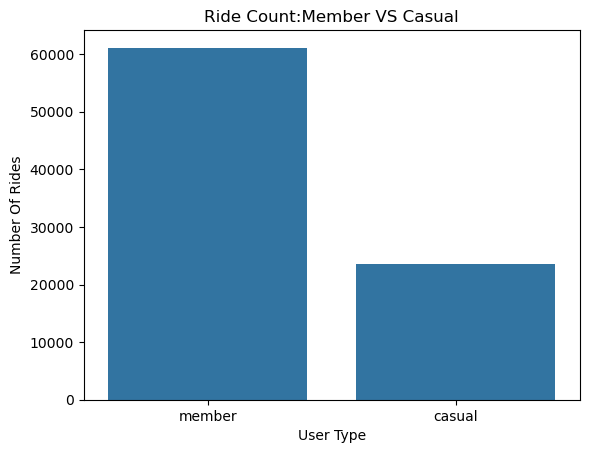

In [28]:
sns.countplot(x='member_casual',data=df)
plt.title("Ride Count:Member VS Casual")
plt.xlabel("User Type")
plt.ylabel("Number Of Rides")
plt.show()


Here we can see that Members domimate the usage 

2.AVG Ride Length 

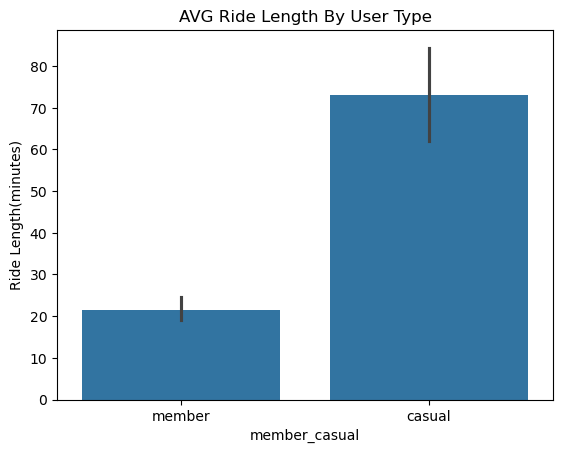

In [29]:
sns.barplot(x='member_casual',y='ride_length',data=df)
plt.title("AVG Ride Length By User Type")
plt.ylabel("Ride Length(minutes)")
plt.show()

Here we can see thet casual ride longer than members 

3.Hour Wise Usage 

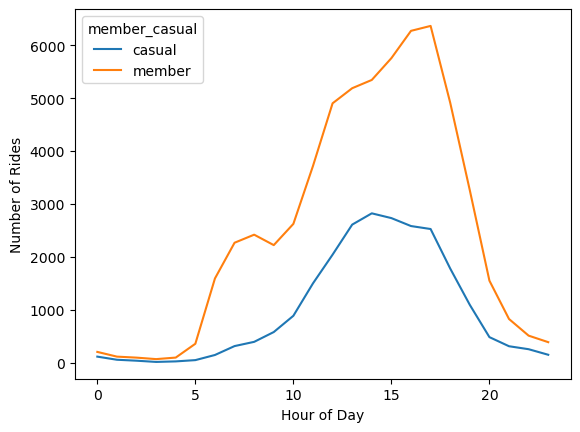

In [37]:
hourly=df.groupby(['hour','member_casual']).size().reset_index(name='count')

sns.lineplot(data=hourly,x='hour',y='count',hue='member_casual')
plt.title=("Hourly Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.show()


Here we can see that Member peaks (commute)
Casual peaks (leisure)

4.Day-wise Usage

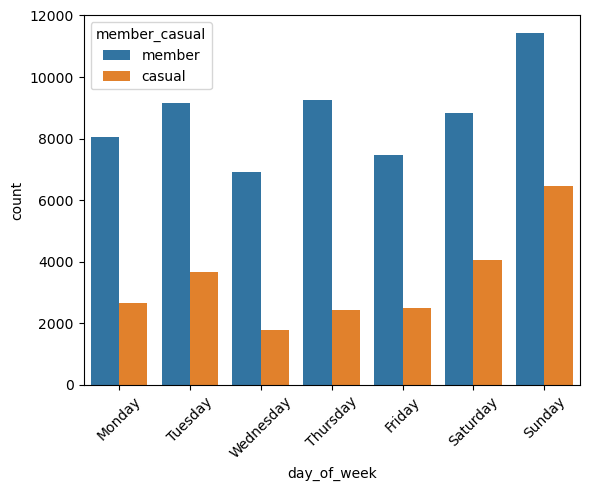

In [38]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='day_of_week', hue='member_casual', data=df, order=day_order)
plt.title=("Usage by Day of Week")
plt.xticks(rotation=45)
plt.show()

Here we can see that on sundays there are most rides taken by both casuals and mambers 